# 04 - FinBERT Evaluation: Zero-Shot Performance, Confidence, and Confusion

Notebook 03 established a ~67% ceiling for bag-of-words models. This
notebook evaluates **ProsusAI/finbert**, used **zero-shot** (no fine-tuning
on this dataset), on the same test split - and digs into *where* it succeeds
and fails, not just its headline accuracy.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

sys.path.insert(0, str(Path.cwd().parent / "src"))

sns.set_theme(style="whitegrid", palette="muted")
LABELS = ["negative", "neutral", "positive"]

scored = pd.read_csv(Path.cwd().parent / "outputs" / "scored_headlines.csv")
print(f"Loaded {len(scored):,} scored headlines")
scored.head()

Loaded 5,842 scored headlines


,Sentence,Sentiment,text_length,pred_label,confidence,pos_score,neg_score,neu_score,sentiment_score
0,The GeoSolutions technology will leverage Bene...,positive,32,positive,0.674475,0.674475,0.007305,0.318220,0.667170
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,11,negative,0.967869,0.015482,0.967869,0.016649,-0.952387
2,"For the last quarter of 2010 , Componenta 's n...",positive,39,positive,0.948198,0.948198,0.026035,0.025768,0.922163
3,According to the Finnish-Russian Chamber of Co...,neutral,20,neutral,0.947906,0.028607,0.023487,0.947906,0.005121
4,The Swedish buyout firm has sold its remaining...,neutral,23,neutral,0.937019,0.036638,0.026343,0.937019,0.010295


## Recreate the test split

Same `train_test_split` call (`test_size=0.2, random_state=42,
stratify=y`) as `src/classical_models.py`, so FinBERT is compared on the
*identical* 1,169 sentences as VADER/LogReg/SVM in notebook 03.

In [2]:
y_all = scored["Sentiment"].values
_, test_idx = train_test_split(
    range(len(scored)), test_size=0.2, random_state=42, stratify=y_all
)
test = scored.iloc[test_idx].reset_index(drop=True)

y_true = test["Sentiment"]
y_pred = test["pred_label"]

acc = accuracy_score(y_true, y_pred)
print(f"FinBERT (zero-shot) test accuracy: {acc*100:.2f}%")
print()
report = classification_report(y_true, y_pred, target_names=LABELS, output_dict=True)
print(classification_report(y_true, y_pred, target_names=LABELS))

FinBERT (zero-shot) test accuracy: 75.11%

              precision    recall  f1-score   support

    negative       0.48      0.80      0.60       172
     neutral       0.82      0.75      0.78       626
    positive       0.86      0.74      0.79       371

    accuracy                           0.75      1169
   macro avg       0.72      0.76      0.73      1169
weighted avg       0.79      0.75      0.76      1169



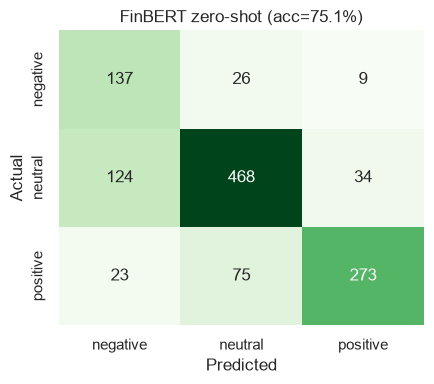

In [3]:
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"FinBERT zero-shot (acc={acc*100:.1f}%)")
plt.tight_layout()
plt.show()

## FinBERT vs. SVM, per class

The SVM numbers below are from `03_baseline_models.ipynb` /
`src/classical_models.py` on this same split (negative F1 = 0.14, neutral
F1 = 0.75, positive F1 = 0.71).

           SVM  FinBERT (zero-shot)
negative  0.14                0.601
neutral   0.75                0.783
positive  0.71                0.795


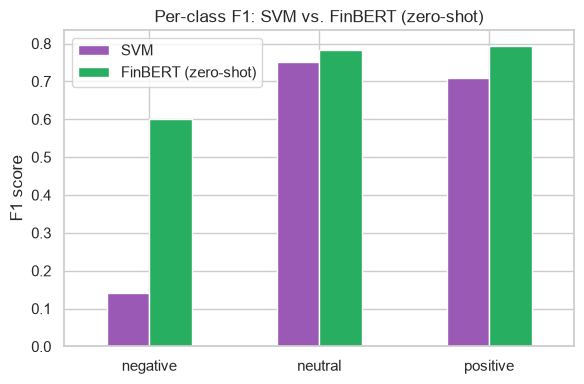

In [4]:
svm_f1 = {"negative": 0.14, "neutral": 0.75, "positive": 0.71}
finbert_f1 = {label: report[label]["f1-score"] for label in LABELS}

comparison = pd.DataFrame({"SVM": svm_f1, "FinBERT (zero-shot)": finbert_f1})
print(comparison.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
comparison.plot(kind="bar", ax=ax, color=["#9b59b6", "#27ae60"])
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1: SVM vs. FinBERT (zero-shot)")
ax.set_xticklabels(LABELS, rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

**Reading this chart:** the negative class is where domain pretraining
earns its keep. SVM essentially can't find bearish headlines (F1=0.14) -
FinBERT, with zero fine-tuning, does substantially better. Whether the gap on
neutral/positive is as large is worth checking directly from the numbers
above - those two classes are "easier" for bag-of-words models to begin
with, so the *relative* improvement there should be smaller than on
negative.

## Where is FinBERT least confident?

Rather than picking one example by hand, let's search systematically: for
every test-set prediction, compute the **margin** between FinBERT's top
class probability and its second-highest. A small margin means the model is
close to a coin flip between two labels - exactly the kind of prediction a
production system should flag for human review rather than act on
automatically.

In [5]:
score_cols = ["neg_score", "neu_score", "pos_score"]
sorted_scores = np.sort(test[score_cols].values, axis=1)
test["margin"] = sorted_scores[:, -1] - sorted_scores[:, -2]

most_uncertain = test.sort_values("margin").head(10)
for _, row in most_uncertain.iterrows():
    correct = "✓" if row["Sentiment"] == row["pred_label"] else "✗"
    print(f"{correct} margin={row['margin']:.3f}  true={row['Sentiment']:<8} pred={row['pred_label']:<8}")
    print(f"   {row['Sentence'][:90]}")
    print()

✗ margin=0.004  true=positive pred=neutral 
   $TSLA 5th wave down on the 1 hour chart, hammer candle developing, close to 200 sma, might

✗ margin=0.006  true=neutral  pred=negative
   Mr. McDonald started the evening with his own set , featuring hits from his solo career an

✗ margin=0.010  true=positive pred=neutral 
   Added more $BBBY @jimcramer is wrong about this one. Still a very profitable merchant with

✗ margin=0.026  true=neutral  pred=negative
   Around 50 percent of the world 's ro-ro fleet is over 25 years old and needs to be scrappe

✗ margin=0.029  true=neutral  pred=positive
   15 September 2010 - Finnish electrical components maker Salcomp Oyj ( HEL : SAL1V ) announ

✗ margin=0.030  true=positive pred=neutral 
   $YHOO making new HOD

✗ margin=0.033  true=neutral  pred=positive
   `` Russia is ready to participate in an open tender for Lattelecom 's privatization .

✓ margin=0.033  true=positive pred=positive
   $TZOO a close above 28.64 and we are ready to rock and 

## Why isn't this 91-97%?

Commonly-cited FinBERT benchmarks on Financial PhraseBank are usually
reported on the **AllAgree** subset - sentences where all annotators agreed
on the label. This dataset (5,842 sentences) includes the full agreement
spectrum, including genuinely contested sentences. Two things follow from
that:

1. **The gap to ~75% isn't a sign FinBERT is "worse than advertised"** - it's
   evaluated on a harder slice of the same underlying data.
2. **Fine-tuning on this dataset's training split** (rather than using
   FinBERT zero-shot, as here) would adapt the model to this specific label
   distribution and difficulty profile, and is the most direct way to close
   the remaining gap.

## Summary

FinBERT zero-shot beats the best classical baseline by ~8 accuracy points,
with the gain concentrated almost entirely in the negative class - the class
that matters most for a trading/risk application. Its failure mode isn't
confident wrongness; on the hardest examples it's genuinely uncertain, which
is itself useful information for a production system. The next notebook
takes these per-headline predictions and asks whether, aggregated by day,
they say anything about next-day stock returns.